In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Thu Nov 27 22:46:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:19:00.0 Off |                  N/A |
|100%   90C    P1            530W /  600W |    8635MiB /  32607MiB |     81%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
os.environ["DPM_TQDM"] = "False"

GMFLOW = os.path.join("submodules", "GMFlow")
sys.path.insert(0, GMFLOW)

In [3]:
from backbones.gmdit import GMDiT

# 사용 예
model = GMDiT()
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:33: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv-full`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '
2025-11-27 22:46:17.494661: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/logpx_samplers/submodules/GMFlow/lib/ops/gmflow_ops/gmflow_ops.py:31: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

cannot get type annotation for Parameter scheduler of <class 'lib.pipelines.gmdit_pipeline.GMDiTPipeline'>.


Loading pipeline components...:   0%|          | 0/4 [00:00<?, ?it/s]

Expected types for id2label: (typing.Dict[int, str], <class 'NoneType'>), got typing.Dict[str, str].


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


In [5]:
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

# 클래스 0–9로 설정
class_start = np.random.randint(0, 900)
#class_start = 0
class_ids = [i for i in range(class_start, class_start+100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
noises = model.get_noise(seeds=class_ids)


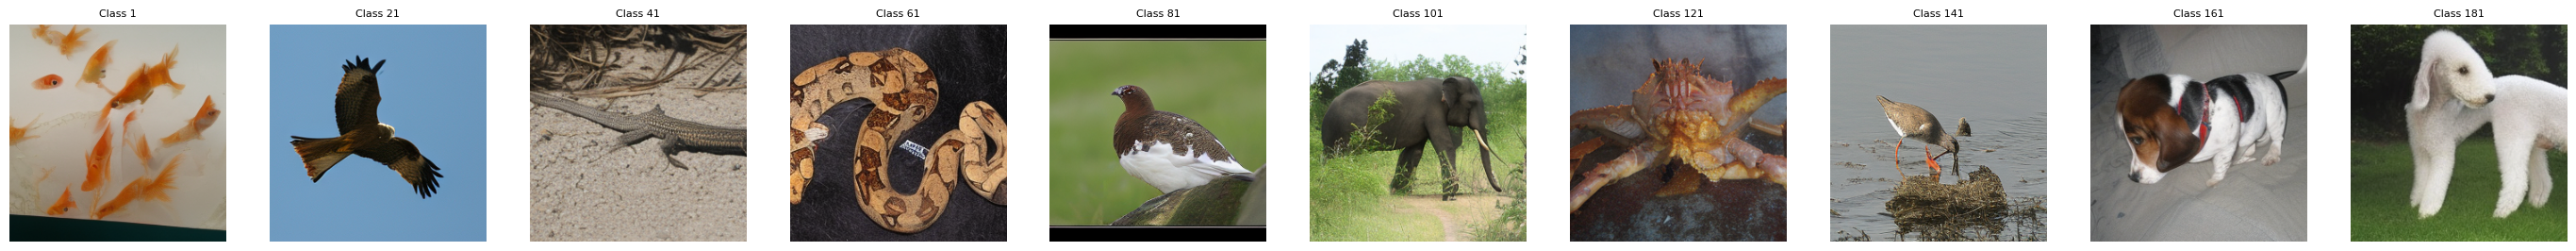

In [6]:
from solvers.others.dpm_solver import DPM_Solver

# 클래스 0–9로 설정
#class_ids = [i for i in range(0, 200, 20)]
class_ids = [i for i in range(1, 201, 20)]
device = 'cuda:0'

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule, pos_conds=class_ids, guidance_scale=1.5)
noises = model.get_noise(seeds=class_ids)
solver = DPM_Solver(noise_schedule, steps=7, order=2,
                skip_type='time_uniform_flow',
                algorithm_type='data_prediction').to(device)
outputs = solver.sample(noises, model_fn)
samples = model.decode_vae(outputs['samples'], pil_output=True)
display_class_images(samples['pil_output'], class_ids)


logs/gmdit/epd_traj/s5/step_00010000.pt


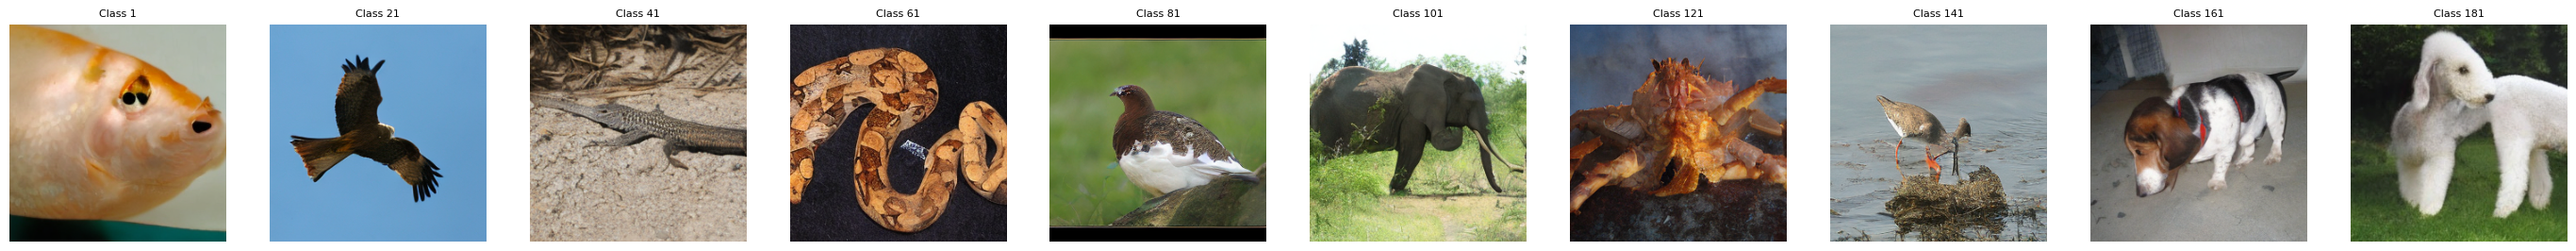

In [7]:
import torch
from solvers.competing.epd.epd_solver_arithmetic import EPD_Solver
from utils.util import get_pt

# 클래스 0–9로 설정
#class_ids = [i for i in range(0, 200, 20)]
class_ids = [i for i in range(1, 201, 20)]
device = 'cuda:0'
NFE = 5

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule, pos_conds=class_ids, guidance_scale=1.4)
noises = model.get_noise(seeds=class_ids)
solver = EPD_Solver(noise_schedule, steps=NFE,
                skip_type='time_uniform_flow',
                flow_shift=1.0,
                algorithm_type='noise_prediction',
                use_afs=True
                ).to(device)

pt_file = get_pt(f'logs/gmdit/epd_traj/s{NFE}', 'latest')
print(pt_file)
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)

with torch.no_grad():
    outputs = solver.sample(noises, model_fn)
    samples = model.decode_vae(outputs['samples'], pil_output=True)
    display_class_images(samples['pil_output'], class_ids)

logs/gmdit/epd_traj_teacher_edm_5e3_10k/s5/step_00005000.pt


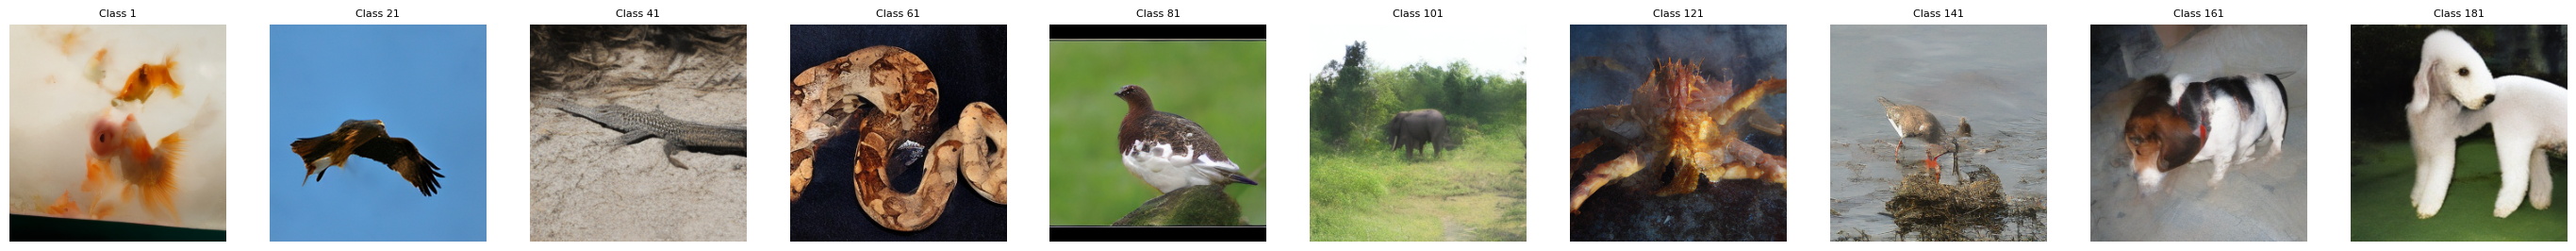

In [8]:
import torch
from solvers.competing.epd.epd_solver_arithmetic import EPD_Solver
from utils.util import get_pt

# 클래스 0–9로 설정
#class_ids = [i for i in range(0, 200, 20)]
class_ids = [i for i in range(1, 201, 20)]
device = 'cuda:0'
NFE = 5

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule, pos_conds=class_ids, guidance_scale=1.4)
noises = model.get_noise(seeds=class_ids)
solver = EPD_Solver(noise_schedule, steps=NFE,
                skip_type='edm',
                flow_shift=1.0,
                algorithm_type='noise_prediction',
                use_afs=True
                ).to(device)

pt_file = get_pt(f'logs/gmdit/epd_traj_teacher_edm_5e3_10k/s{NFE}', 'latest')
print(pt_file)
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)

with torch.no_grad():
    outputs = solver.sample(noises, model_fn)
    samples = model.decode_vae(outputs['samples'], pil_output=True)
    display_class_images(samples['pil_output'], class_ids)